In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from graphviz import Digraph

2.000000165480742e-05

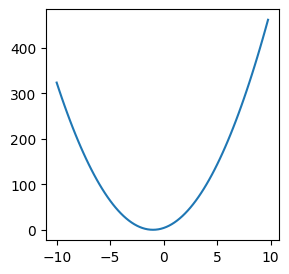

In [3]:
def f(x):
    return 4*x**2 + 8*x + 4

xs = np.arange(-10, 10, 0.25)
ys = f(xs)

plt.figure(figsize=(3,3))
plt.plot(xs, ys)

h = 0.000005
x = -1
(f(x+h) - f(x))/h

In [4]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
d2 = (a+h)*b + c
d3 = a*(b+h) + c
d4 = a*b + (c+h)

print(f"d1 : {d1}, d2 : {d2}, d3 : {d3}, d4 : {d4}")
print(f"slope wrt to a : {(d2-d1)/h}")
print(f"slope wrt to b : {(d3-d1)/h}")
print(f"slope wrt to c : {(d4-d1)/h}")

d1 : 4.0, d2 : 3.999699999999999, d3 : 4.0002, d4 : 4.0001
slope wrt to a : -3.000000000010772
slope wrt to b : 2.0000000000042206
slope wrt to c : 0.9999999999976694


In [36]:
class Value:

    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data: {self.data}, label: {self.label})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __radd__(self, other):    # int + Value
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    def __rmul__(self, other):    # int * Value
        return self * other

    def __neg__(self):
        return self * -1

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other):
        return other * self**-1

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += (out.data * out.grad)
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def backward(self):
      topo = []
      visited = set()
      def build_topo(v):
        if v not in visited:
          visited.add(v)
          for child in v._prev:
            build_topo(child)
          topo.append(v)

      build_topo(self)
      self.grad = 1
      for node in topo[::-1]:
        node._backward()

In [15]:
a = Value(2, label='a')
b = Value(-3, label = 'b')
c = Value(10, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2, label = 'f')

L = d * f; L.label = 'L'

print(d, d._prev, d._op)
print(L)

Value(data: 4, label: d) {Value(data: 10, label: c), Value(data: -6, label: e)} +
Value(data: -8, label: L)


In [16]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):

    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


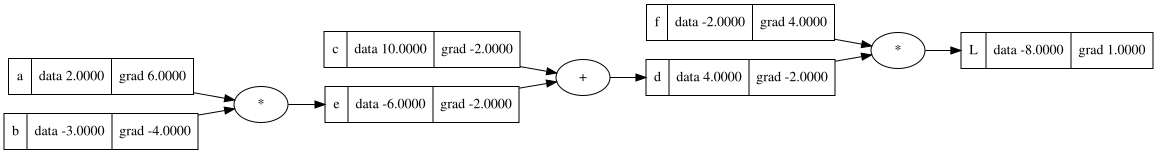

In [17]:
#draw_dot(d)
L.backward()
draw_dot(L)

In [9]:
#sample neuron

#sample input
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#sample weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#sample bias
b = Value(6.8813735870195432, label='b')

#z = x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

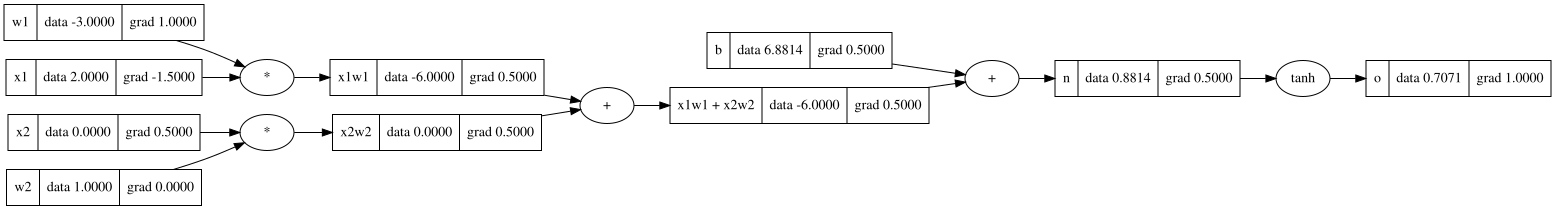

In [10]:
o.backward()
draw_dot(o)

Topological Sort to replace:

1. o._backward()
2. n._backward()
3. b._backward()
4. x1w1x2w2._backward()
5. x1w1._backward()
6. x2w2._backward()
7. x1._backward()
8. x2._backward()
9. w1._backward()
10. w2._backward()

In [11]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(o)

o.grad = 1
for node in topo[::-1]:
  node._backward()

Bad bug if in -> **__add__ _backward**:

1. self.grad = out.grad
2. other.grad = out.grad

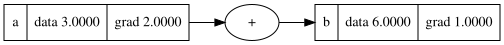

In [12]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'  #a.grad = 2 not 1 unlike in this case
b.backward()
draw_dot(b)

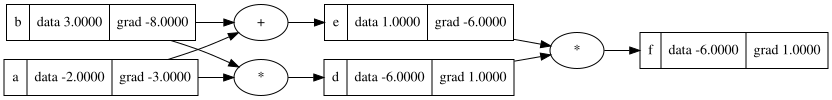

In [13]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a*b; d.label = 'd'
e = a+b; e.label = 'e'
f = d*e; f.label = 'f'

# df/da and df/db calculated wrong :
# cause : same variable used multiple times
# solution : accumulate the gradients by using -> self.grad += (whatever  we wrote previously) and other.grad += (whatever  we wrote previously)

f.backward()
draw_dot(f)

More operations

Value(data: 3.0, label: )
Value(data: 4.0, label: )
Value(data: 1.0, label: )
Value(data: -2.0, label: )
Value(data: 7.38905609893065, label: )
Value(data: 4.0, label: b) Value(data: 6.0, label: c)


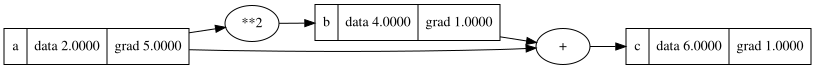

In [28]:
a = Value(2.0, label='a')
print(1+a)
print(2*a)
print(a/2)
print(-a)
print(a.exp())

b = a**2; b.label='b'
c = a + b; c.label = 'c'

print(b, c)
c.backward()
draw_dot(c)

Comparison with pytorch

In [30]:
import torch

In [33]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("---")
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


Neuron

In [37]:
import random

In [52]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for i in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w*x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out




Value(data: 0.912731211437177, label: )

In [74]:
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if (len(outs) == 1) else outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

x = [2.0, 3.0, -1.0]  #input
n = MLP(3, [4, 4, 1]) #no input, [no of neurons in hidden layers + final output layer]
n(x)

Value(data: -0.9260589609680614, label: )

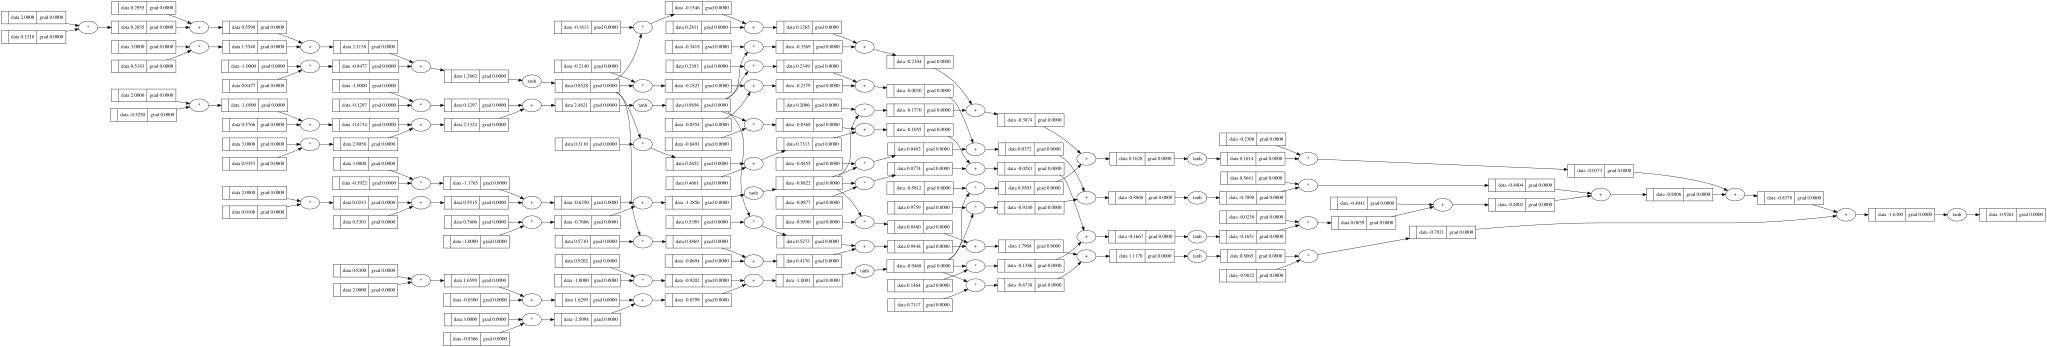

In [75]:
draw_dot(n(x))